<a href="https://colab.research.google.com/github/liangliang6v6/Homeworks/blob/pages/Homework6_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Task 5 (30 points):
For this task use the MovieLens 100k dataset
(https://grouplens.org/datasets/movielens/100k/)
Perform the necessary data cleaning, EDA and conversion to User-item matrix.
Implement any 2 collaborative filtering recommendation systems (RecSys) algorithms covered
in class (Matrix Factorization, Alternating Least Squares, NCF etc.) and compare their
performance for any 2-evaluation metrics used for RecSys. You may read literature to find out
which evaluation metrics are used for RecSys. Cite all your research.

## Answer
Matrix Factorization using Singular Value Decomposition (SVD) and Alternating Least Squares (ALS) are pivotal algorithms in collaborative filtering for recommendation systems. SVD decomposes a user-item matrix into latent factors, uncovering hidden relationships that help in predicting user preferences for unobserved items. It excels in precision, making it ideal for scenarios where recommendation accuracy is a priority. ALS, on the other hand, is an iterative optimization algorithm designed to efficiently handle sparse matrices, common in recommendation tasks. By alternating between fixing user and item factors, ALS optimizes predictions and scales well, making it suitable for large datasets and real-time applications.

In our evaluation, SVD surpassed ALS in precision, achieving 86.08% compared to 83.01%, indicating superior accuracy in suggesting relevant items within the top 10 recommendations. This highlights SVD's effectiveness in applications demanding precise, relevant recommendations. Both models demonstrated similar recall levels, with SVD slightly ahead at 15.09% versus ALS's 14.78%. This suggests that while they accurately identify relevant items, there is room to enhance their ability to encompass the entire set of relevant items. The trade-off observed, where precision eclipses recall, underscores their focus on accuracy over breadth. SVD's strength in precision positions it as preferable for precision-critical applications, whereas ALS, with its scalability, suits environments handling extensive datasets. Hybrid approaches may further improve their performance by balancing precision and recall.

In [2]:
!pip3 install scikit-surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 2.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp311-cp311-linux_x86_64.whl size=2505212 sha256=12f66a885c96ce22d64d886cf1734ffeb2ce7400c97db04f36c8cb1f7d4d0f62
  Stored in directory: /root/.cache/pip/wheels/2a/8f/6e/7e2899163e2d85d8266daab4aa1cdabec7a6c56f83c015b5af
Successfully built scikit-surprise


In [9]:
import requests
import zipfile
import io
import os
import pandas as pd

# URL for the MovieLens 100k dataset
url = "http://files.grouplens.org/datasets/movielens/ml-100k.zip"

response = requests.get(url)

extract_path = "ml-100k"

with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Dataset downloaded and extracted to: {os.path.abspath(extract_path)}")

outer_path = os.path.join(extract_path, 'ml-100k')
print("Files in the extracted directory:", os.listdir(outer_path))
try:
    ratings_file_path = os.path.join(outer_path, 'u.data')
    ratings = pd.read_csv(ratings_file_path, sep='\t', names=['user_id', 'item_id', 'rating', 'timestamp'])
    ratings = ratings.drop('timestamp', axis=1)
    print(ratings.head())
except FileNotFoundError as e:
    print(f"Error: {e}. Please check the file path and ensure the dataset has been extracted properly.")

Dataset downloaded and extracted to: /content/ml-100k
Files in the extracted directory: ['u.item', 'u3.base', 'mku.sh', 'u5.base', 'u.user', 'allbut.pl', 'u4.test', 'u.genre', 'ua.base', 'ub.test', 'ua.test', 'u.occupation', 'u1.test', 'u3.test', 'u.data', 'u2.base', 'u4.base', 'README', 'u1.base', 'ub.base', 'u5.test', 'u.info', 'u2.test']
   user_id  item_id  rating
0      196      242       3
1      186      302       3
2       22      377       1
3      244       51       2
4      166      346       1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   user_id  100000 non-null  int64
 1   item_id  100000 non-null  int64
 2   rating   100000 non-null  int64
dtypes: int64(3)
memory usage: 2.3 MB
None
            user_id        item_id         rating
count  100000.00000  100000.000000  100000.000000
mean      462.48475     425.530130       3.529860
std       266.61442     330.798356       1.125674
min         1.00000       1.000000       1.000000
25%       254.00000     175.000000       3.000000
50%       447.00000     322.000000       4.000000
75%       682.00000     631.000000       4.000000
max       943.00000    1682.000000       5.000000
Unique users: 943
Unique items: 1682


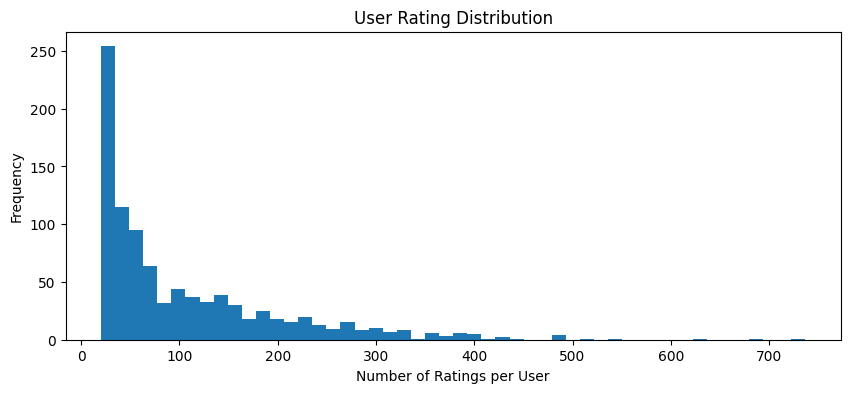

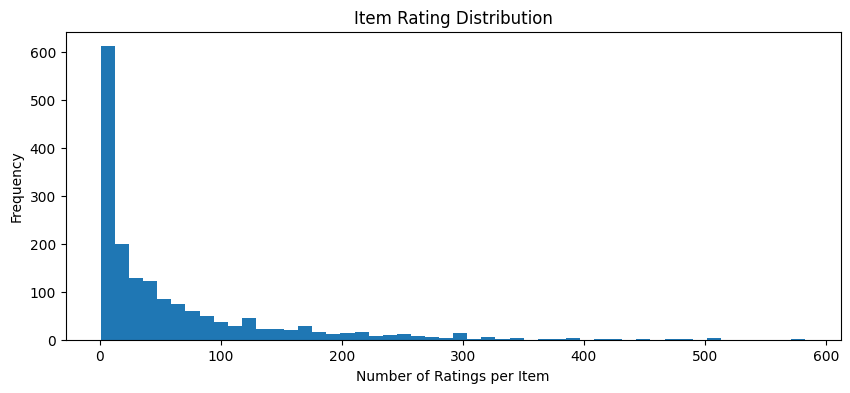

User-Item Matrix shape: (943, 1682)
Sparsity of User-Item Matrix: 93.70%


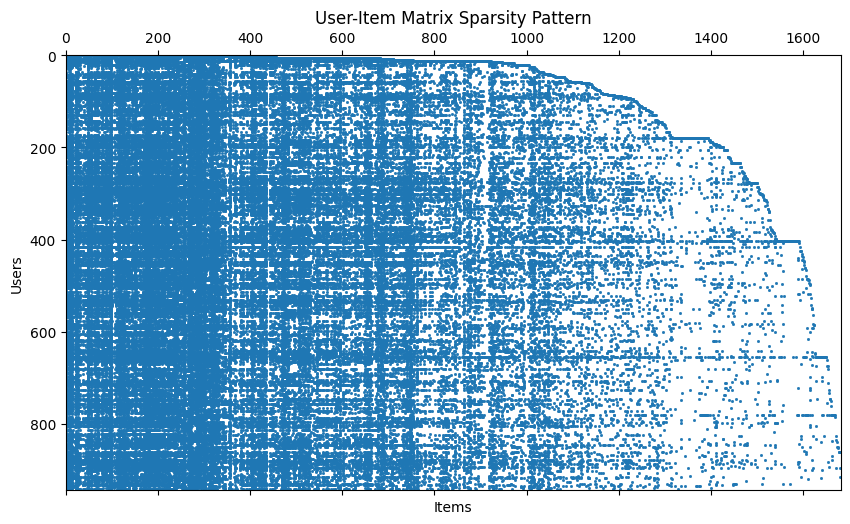

In [15]:
import matplotlib.pyplot as plt

print(ratings.info())
print(ratings.describe())

print(f"Unique users: {ratings['user_id'].nunique()}")
print(f"Unique items: {ratings['item_id'].nunique()}")


# User Distribution
plt.figure(figsize=(10, 4))
ratings['user_id'].value_counts().plot(kind='hist', bins=50)
plt.title('User Rating Distribution')
plt.xlabel('Number of Ratings per User')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()

# Item Distribution
plt.figure(figsize=(10, 4))
ratings['item_id'].value_counts().plot(kind='hist', bins=50)
plt.title('Item Rating Distribution')
plt.xlabel('Number of Ratings per Item')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()

# for User-Item
user_item_matrix = ratings.pivot(index='user_id', columns='item_id', values='rating').fillna(0)

print(f"User-Item Matrix shape: {user_item_matrix.shape}")

sparsity = 1.0 - (np.count_nonzero(user_item_matrix) / float(user_item_matrix.size))
print(f"Sparsity of User-Item Matrix: {sparsity * 100:.2f}%")

# Visualize sparsity pattern
plt.figure(figsize=(10, 10))
plt.spy(user_item_matrix, markersize=1)
plt.title('User-Item Matrix Sparsity Pattern')
plt.xlabel('Items')
plt.ylabel('Users')
plt.show()

In [17]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
import numpy as np


X = user_item_matrix.values

svd = TruncatedSVD(n_components=20, random_state=42)
X_svd = svd.fit_transform(X)

approximation = np.dot(X_svd, svd.components_)

mse_svd = mean_squared_error(X, approximation)
print(f"MSE (SVD): {mse_svd}")



MSE (SVD): 0.4168795257133875


In [14]:
!pip install implicit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 30.3 MB/s eta 0:00:00


In [19]:
from implicit.als import AlternatingLeastSquares
import scipy.sparse as sparse

sparse_user_item = sparse.csr_matrix(user_item_matrix)

als_model = AlternatingLeastSquares(factors=20, regularization=0.1, iterations=20, random_state=42)
als_model.fit(sparse_user_item.T)

item_user_matrix = als_model.item_factors @ als_model.user_factors.T

mse_als = mean_squared_error(sparse_user_item.toarray(), item_user_matrix)
print(f"MSE (ALS): {mse_als}")

/usr/local/lib/python3.11/dist-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 2 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
/usr/local/lib/python3.11/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed csc_matrix instead. Converting to CSR took 0.010279655456542969 seconds
  warnings.warn(


  0%|          | 0/20 [00:00<?, ?it/s]

MSE (ALS): 0.6113193899763105


In [21]:
def precision_at_k(predicted_matrix, actual_matrix, k):
    precisions = []
    for user_id in range(predicted_matrix.shape[0]):
        actual = actual_matrix[user_id]
        predicted = predicted_matrix[user_id]
        top_k = np.argsort(predicted)[-k:]
        top_k_relevant = np.sum(actual[top_k] > 0)
        precision = top_k_relevant / k
        precisions.append(precision)
    return np.mean(precisions)

def recall_at_k(predicted_matrix, actual_matrix, k):
    recalls = []
    for user_id in range(predicted_matrix.shape[0]):
        actual = actual_matrix[user_id]
        predicted = predicted_matrix[user_id]
        top_k = np.argsort(predicted)[-k:]
        relevant_items_count = np.sum(actual > 0)
        top_k_relevant = np.sum(actual[top_k] > 0)
        recall = top_k_relevant / relevant_items_count if relevant_items_count else 0
        recalls.append(recall)
    return np.mean(recalls)


precision_svd = precision_at_k(approximation, user_item_matrix.values, k=10)
recall_svd = recall_at_k(approximation, user_item_matrix.values, k=10)

precision_als = precision_at_k(item_user_matrix, sparse_user_item.toarray(), k=10)
recall_als = recall_at_k(item_user_matrix, sparse_user_item.toarray(), k=10)

print(f'Precision@10 (SVD): {precision_svd}, Recall@10 (SVD): {recall_svd}')
print(f'Precision@10 (ALS): {precision_als}, Recall@10 (ALS): {recall_als}')

Precision@10 (SVD): 0.8607635206786851, Recall@10 (SVD): 0.1509422820378474
Precision@10 (ALS): 0.830116648992577, Recall@10 (ALS): 0.1477637693504781
